# 1. Importing Libraries

#### 1.1. Sklearn Libraries

In [ ]:
from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import PowerTransformer, StandardScaler

#### 1.2. MatPlotLib Libraries

In [1436]:
import matplotlib
from matplotlib import colors
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt, numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Circle, FancyArrowPatch, Rectangle

In [1354]:
import pandas as pd
import datetime
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer
from mpl_toolkits.mplot3d import Axes3D
import warnings
import sys
if not sys.warnoptions:
    warnings.simplefilter("ignore")
np.random.seed(42)
from scipy.stats import ttest_ind

In [1435]:
from dataclasses import dataclass
from itertools import combinations
from typing import Any

from IPython.display import display
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
from factor_analyzer.rotator import Rotator

import math
from typing import Optional

# 2. Load Data

In [1356]:
df = pd.read_csv("raw_data.csv")

# 3. Inspect Data

#### 3.1. Making sure data doesn't get truncated

In [1357]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

#### 3.2. Checking sample size and variables

In [1358]:
print(df.shape)

(2240, 29)


In [1359]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

#### 3.3. Checking missing values

In [1360]:
print(df.isnull().sum())

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


*Note: Rows with missing income values will be removed later during preprocessing.*

#### 3.4. Checking duplicates

In [1361]:
df[df.duplicated()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response


In [1362]:
df[df.duplicated(subset="ID", keep=False)]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response


#### 3.5. Checking FDTs of variables

In [1363]:
# Totals in categories in Education
print(df["Education"].value_counts())

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


In [1364]:
# Totals in categories in Marital_Status
print(df["Marital_Status"].value_counts(), "\n")

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64 



#### 3.6. Checking values of variables

##### 3.5.1. Inspecting income

In [1365]:
print(df["Income"].value_counts().sort_index(), "\n")

Income
1730.0       1
2447.0       1
3502.0       1
4023.0       1
4428.0       1
4861.0       1
5305.0       1
5648.0       1
6560.0       1
6835.0       1
7144.0       1
7500.0      12
8028.0       1
8820.0       1
8940.0       1
9255.0       1
9548.0       1
9722.0       1
10245.0      1
10404.0      1
10979.0      2
11012.0      1
11448.0      1
12393.0      1
12571.0      1
13084.0      1
13260.0      1
13533.0      1
13624.0      1
13672.0      1
13724.0      1
14045.0      1
14188.0      1
14421.0      1
14515.0      1
14661.0      1
14796.0      1
14849.0      1
14906.0      1
14918.0      1
15033.0      1
15038.0      1
15056.0      1
15072.0      1
15253.0      1
15287.0      2
15315.0      2
15345.0      1
15716.0      1
15759.0      1
15862.0      1
16005.0      1
16014.0      1
16185.0      1
16248.0      1
16269.0      1
16529.0      1
16531.0      1
16581.0      1
16626.0      1
16653.0      1
16813.0      1
16860.0      1
16927.0      1
17003.0      1
17117.0      1
171

In [1366]:
df[["Income"]].describe()

,Income
count,2216.000000
mean,52247.251354
std,25173.076661
min,1730.000000
25%,35303.000000
50%,51381.500000
75%,68522.000000
max,666666.000000


In [1367]:
df[df["Income"] == 666666]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2233,9432,1977,Graduation,Together,666666.0,1,0,02/06/2013,23,9,14,18,8,1,12,4,3,1,3,6,0,0,0,0,0,0,3,11,0


*Note: The income doesn't make sense relative to the user's spending.
This outlier will be dropped later in preprocessing.*

##### 3.5.2. Inspecting children

In [1368]:
print("Total Kids:", df["Kidhome"].sum())
print("Total Teens:", df["Teenhome"].sum())

Total Kids: 995
Total Teens: 1134


##### 3.5.3. Inspecting customer tenure

In [1369]:
# Earliest and Latest Customer

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

print(df["Dt_Customer"].max())
print(df["Dt_Customer"].min())

2014-06-29 00:00:00
2012-07-30 00:00:00


##### 3.5.4. Inspecting Products

In [1370]:
df[["MntWines",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"]].describe()

,MntWines,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,303.935714,166.950000,37.525446,27.062946,44.021875
std,336.597393,225.715373,54.628979,41.280498,52.167439
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.750000,16.000000,3.000000,1.000000,9.000000
50%,173.500000,67.000000,12.000000,8.000000,24.000000
75%,504.250000,232.000000,50.000000,33.000000,56.000000
max,1493.000000,1725.000000,259.000000,263.000000,362.000000


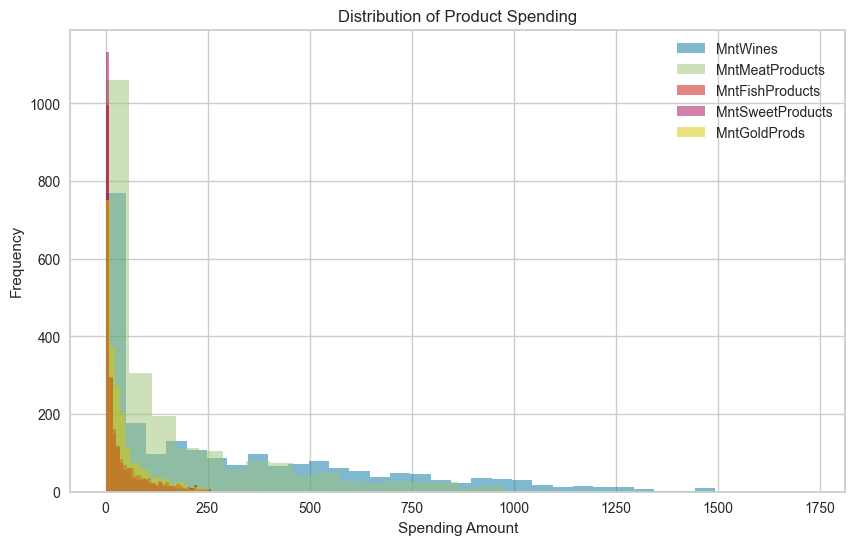

In [1371]:
product_cols = ["MntWines",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"]

plt.figure(figsize=(10,6))

for col in product_cols:
    plt.hist(
        df[col].dropna(),
        bins=30,
        alpha=0.5,
        label=col
    )

plt.xlabel("Spending Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Product Spending")
plt.legend()

plt.show()

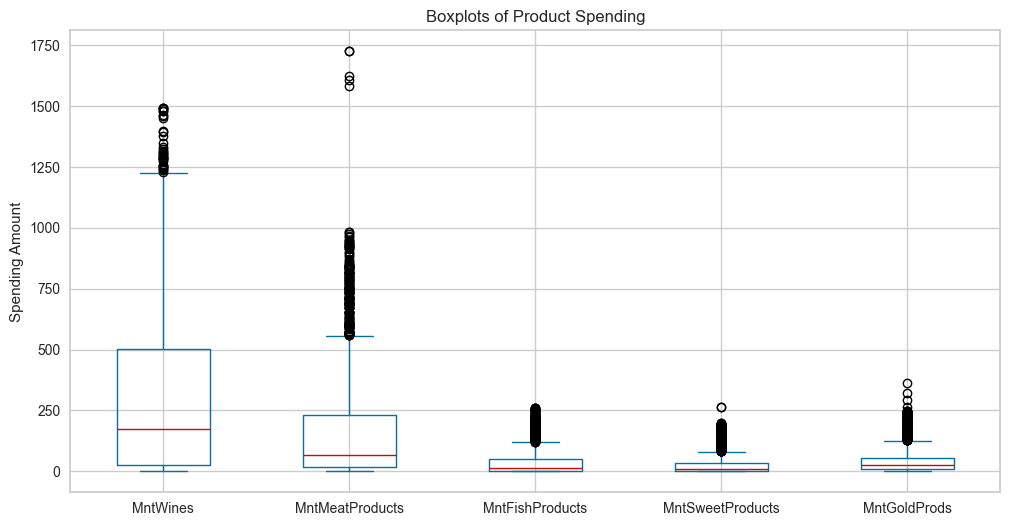

In [1372]:
df[product_cols].plot(
    kind="box",
    figsize=(12,6)
)

plt.title("Boxplots of Product Spending")
plt.ylabel("Spending Amount")

plt.show()

In [1373]:
purchase_cols = [
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

purchase_summary = df[purchase_cols].describe().T

display(purchase_summary)

,count,mean,std,min,25%,50%,75%,max
NumDealsPurchases,2240.0,2.325000,1.932238,0.0,1.0,2.0,3.0,15.0
NumWebPurchases,2240.0,4.084821,2.778714,0.0,2.0,4.0,6.0,27.0
NumCatalogPurchases,2240.0,2.662054,2.923101,0.0,0.0,2.0,4.0,28.0
NumStorePurchases,2240.0,5.790179,3.250958,0.0,3.0,5.0,8.0,13.0
NumWebVisitsMonth,2240.0,5.316518,2.426645,0.0,3.0,6.0,7.0,20.0


In [1374]:
purchases_fdt = pd.DataFrame({
    "Frequency": df[[
        "NumDealsPurchases",
        "NumWebPurchases",
        "NumCatalogPurchases",
        "NumStorePurchases",
        "NumWebVisitsMonth"
    ]].sum(),

    "Percent": (
        df[[
            "NumDealsPurchases",
            "NumWebPurchases",
            "NumCatalogPurchases",
            "NumStorePurchases",
            "NumWebVisitsMonth"
        ]].mean() * 100
    ).round(2)
})

purchases_fdt

,Frequency,Percent
NumDealsPurchases,5208,232.50
NumWebPurchases,9150,408.48
NumCatalogPurchases,5963,266.21
NumStorePurchases,12970,579.02
NumWebVisitsMonth,11909,531.65


In [1375]:
campaign_fdt = pd.DataFrame({
    "Frequency": df[[
        "AcceptedCmp1",
        "AcceptedCmp2",
        "AcceptedCmp3",
        "AcceptedCmp4",
        "AcceptedCmp5",
        "Response"
    ]].sum(),

    "Percent": (
        df[[
            "AcceptedCmp1",
            "AcceptedCmp2",
            "AcceptedCmp3",
            "AcceptedCmp4",
            "AcceptedCmp5",
            "Response"
        ]].mean() * 100
    ).round(2)
})

campaign_fdt

,Frequency,Percent
AcceptedCmp1,144,6.43
AcceptedCmp2,30,1.34
AcceptedCmp3,163,7.28
AcceptedCmp4,167,7.46
AcceptedCmp5,163,7.28
Response,334,14.91


In [1376]:
print(df["Complain"].value_counts(), "\n")

Complain
0    2219
1      21
Name: count, dtype: int64 



In [1377]:
df[["Z_CostContact", "Z_Revenue"]].describe()

,Z_CostContact,Z_Revenue
count,2240.0,2240.0
mean,3.0,11.0
std,0.0,0.0
min,3.0,11.0
25%,3.0,11.0
50%,3.0,11.0
75%,3.0,11.0
max,3.0,11.0


#### 3.7. Checking relationships between variables

In [1378]:
#Correlation between products

product_cols= [
    "MntWines",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df[product_cols].corr()

,MntWines,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
MntWines,1.000000,0.562667,0.399753,0.386581,0.387516
MntMeatProducts,0.562667,1.000000,0.568402,0.523846,0.350609
MntFishProducts,0.399753,0.568402,1.000000,0.579870,0.422875
MntSweetProducts,0.386581,0.523846,0.579870,1.000000,0.369724
MntGoldProds,0.387516,0.350609,0.422875,0.369724,1.000000


In [1379]:
ProductChild1_cols= [
    "Kidhome",
    "Teenhome",
    "MntWines",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df[ProductChild1_cols].corr().iloc[:, :2]

,Kidhome,Teenhome
Kidhome,1.000000,-0.036133
Teenhome,-0.036133,1.000000
MntWines,-0.496297,0.004846
MntMeatProducts,-0.437129,-0.261160
MntFishProducts,-0.387644,-0.204187
MntSweetProducts,-0.370673,-0.162475
MntGoldProds,-0.349595,-0.021725


In [1380]:
# Correlation between campaigns

campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

df[campaign_cols].corr()

,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
AcceptedCmp1,1.000000,0.175315,0.094751,0.251300,0.403078,0.293982
AcceptedCmp2,0.175315,1.000000,0.072020,0.292210,0.221533,0.169293
AcceptedCmp3,0.094751,0.072020,1.000000,-0.079512,0.080316,0.254258
AcceptedCmp4,0.251300,0.292210,-0.079512,1.000000,0.306526,0.177019
AcceptedCmp5,0.403078,0.221533,0.080316,0.306526,1.000000,0.326634
Response,0.293982,0.169293,0.254258,0.177019,0.326634,1.000000


# 4. Minimal Cleaning

#### 4.1. Dropping rows with missing or unhelpful data

In [1381]:
# Drop rows with missing Income
df = df.dropna(subset=["Income"])

In [1382]:
# Drop rows with YOLO & Absurd under Marital Status
df = df[~df["Marital_Status"].isin(["YOLO", "Absurd"])]

#### 4.2. Renaming Categories

In [1383]:
#Merge Single, Divorced, Widow, & Alone
df["Marital_Status"] = df["Marital_Status"].replace({
    "Divorced": "Single",
    "Widow": "Single",
    "Alone": "Single"
})

#### 4.3. Encoding Categories

In [1384]:
#Encoding Marital_Status
df["Marital_Status"] = df["Marital_Status"].replace({
    "Married": 1,
    "Together": 2,
    "Single": 3
}).astype(int)

In [1385]:
#Encoding Educational Groups
df["Education"] = df["Education"].replace({
    "Basic": 1, #Pre-Bachelor
    "2n Cycle": 1, #Pre-Bachelor
    "Graduation": 2, #Bachelor's Degree
    "Master": 3, #Postgraduate
    "PhD": 3, #Postgraduate
}).astype(int)

# 4. Feature Engineering

#### 4.1. Foundational Engineered Variables

These variables were engineered from raw dataset attributes to serve as foundational behavioral metrics for constructing more advanced customer behavior and preference variables. These variables also served as intermediate behavioral metrics for constructing more advanced ratio- and preference-based variables later in the analysis.

In [1386]:
# Total Children
df["TotalChildren"] = df["Kidhome"] + df["Teenhome"]

In [1387]:
# Total Spending
df["TotalSpending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

In [1388]:
# Total Purchases
df["TotalPurchases"] = (
    df["NumWebPurchases"] +
    df["NumCatalogPurchases"] +
    df["NumStorePurchases"]
)

In [1389]:
# Total Campaigns Accepted
df["TotalCampaignsAccepted"] = (
    df["AcceptedCmp1"] +
    df["AcceptedCmp2"] +
    df["AcceptedCmp3"] +
    df["AcceptedCmp4"] +
    df["AcceptedCmp5"] +
    df["Response"]
)

#### 4.2. Core Structural Variables

These variables were engineered to represent the customer's demographic profile, household structure, and lifecycle characteristics. They help provide foundational context about the customer's living situation, family composition, and relationship with the company over time.

In [1390]:
# Age of Customer Today
df["Age"] = 2021 - df["Year_Birth"]

In [1391]:
# Number of Family Members
df["FamilySize"] = (
    df["TotalChildren"] +
    1 +
    df["Marital_Status"].isin([1, 2]).astype(int)
)

In [1392]:
# Total Duration a Customer Has Been With the Company

reference_date = df["Dt_Customer"].max()

df["CustomerTenureDays"] = (
    reference_date - df["Dt_Customer"]
).dt.days

#### 4.3. Spending Behavior Variables

These variables were engineered to capture customer spending intensity, purchasing capacity, and product preference behavior. They help identify differences in consumption patterns, premium spending tendencies, and overall purchasing behavior.

In [1393]:
# Spending-to-Income Ratio
df["SpendingIncomeRatio"] = (
    df["TotalSpending"] / df["Income"]
)

#### 4.4. Purchasing Behavior Variables

These variables were engineered to represent how customers make purchases across different shopping channels. They help describe digital purchasing preference, browsing-to-purchase efficiency, and deal-seeking behavior.

In [1394]:
# Web Purchase Preference
df["WebPurchaseRatio"] = (
    df["NumWebPurchases"] /
    (df["TotalPurchases"] + 1)
)

In [1395]:
# Store Purchase Prefence
df["StorePurchaseRatio"] = (
    df["NumStorePurchases"] /
    (df["TotalPurchases"] + 1)
)

In [1396]:
# Web Conversion Rate
df["WebConversionRate"] = (
    df["NumWebPurchases"] /
    (df["NumWebVisitsMonth"] + 1)
)

In [1397]:
# Deal-seeking Tendency
df["DealPurchaseRatio"] = (
    df["NumDealsPurchases"] /
    (df["TotalPurchases"] + 1)
)

#### 4.5. Marketing Responsiveness Variables

These variables were engineered to measure customer responsiveness to marketing campaigns and promotional activities. They help assess customer engagement and likelihood of responding to future campaigns.

In [1398]:
# Campaign Acceptance Rate
df["CampaignAcceptanceRate"] = (
    df["TotalCampaignsAccepted"] / 6
)

#### 4.6. Interpretation/Profiling Variables

These engineered variables were created to support post-clustering interpretation and customer profiling rather than directly drive cluster formation. These variables help provide richer behavioral descriptions and business insights for each identified customer segment.

In [1399]:
# If Person is Parent or Not
df["Is_Parent"] = np.where(
    (df["Kidhome"] + df["Teenhome"]) > 0,
    1,
    0
)

In [1400]:
# Wine Spending Ratio
df["WineSpendingRatio"] = (
    df["MntWines"] / (df["TotalSpending"] + 1)
)

In [1401]:
# Meat Spending Ratio
df["MeatSpendingRatio"] = (
    df["MntMeatProducts"] / (df["TotalSpending"] + 1)
)

In [1402]:
# Total Food Spending
df["TotalFoodSpending"] = (
    df["MntWines"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"]
)

# 5. Inspecting New Features

In [1403]:
#Totals in categories in Age
print(df["Age"].value_counts().sort_index(), "\n")

Age
25      2
26      5
27      3
28      4
29     13
30     15
31     18
32     29
33     29
34     27
35     41
36     32
37     38
38     41
39     44
40     38
41     39
42     53
43     76
44     52
45     89
46     83
47     69
48     70
49     78
50     86
51     75
52     70
53     51
54     44
55     50
56     74
57     41
58     44
59     44
60     35
61     49
62     50
63     52
64     40
65     55
66     48
67     49
68     35
69     52
70     42
71     29
72     30
73     21
74     16
75     16
76      8
77      7
78      6
80      1
81      1
121     1
122     1
128     1
Name: count, dtype: int64 



In [1404]:
df[["Age"]].describe()

,Age
count,2212.000000
mean,52.188969
std,11.982065
min,25.000000
25%,44.000000
50%,51.000000
75%,62.000000
max,128.000000


In [1405]:
#Totals in categories in TotalChildren
print(df["TotalChildren"].value_counts().sort_index(), "\n")

TotalChildren
0     631
1    1115
2     416
3      50
Name: count, dtype: int64 



In [1406]:
#Totals in categories in Is_parent
print(df["Is_Parent"].value_counts().sort_index(), "\n")

Is_Parent
0     631
1    1581
Name: count, dtype: int64 



In [1407]:
df.groupby("Is_Parent")[[
    "TotalSpending",
    "MntWines",
    "NumWebPurchases",
    "Recency"
]].mean()

,TotalSpending,MntWines,NumWebPurchases,Recency
Is_Parent,,,,
0,1104.971474,488.492868,4.408875,48.885895
1,407.848830,231.808349,3.953194,49.116382


In [1408]:
parent_cols= [
    "Is_Parent",
    "MntMeatProducts",
    "TotalSpending",
    "TotalFoodSpending",
    "NumCatalogPurchases",
    "MntFishProducts",
    "MntFruits",
    "MntSweetProducts",
    "NumWebVisitsMonth"
]

df[parent_cols].corr().iloc[:, :1]

,Is_Parent
Is_Parent,1.000000
MntMeatProducts,-0.574821
TotalSpending,-0.521997
TotalFoodSpending,-0.515701
NumCatalogPurchases,-0.452151
MntFishProducts,-0.448159
MntFruits,-0.410575
MntSweetProducts,-0.402959
NumWebVisitsMonth,0.474779


In [1409]:
ProductChild2_cols= [
    "TotalChildren",
    "MntWines",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
]

df[ProductChild2_cols].corr().iloc[:, :1]

,TotalChildren
TotalChildren,1.000000
MntWines,-0.353859
MntMeatProducts,-0.504453
MntFishProducts,-0.426497
MntSweetProducts,-0.389718
MntGoldProds,-0.266807


In [1410]:
df[["CustomerTenureDays"]].describe()

,CustomerTenureDays
count,2212.000000
mean,353.272152
std,202.376279
min,0.000000
25%,180.000000
50%,355.000000
75%,529.000000
max,699.000000


In [1411]:
#Totals in categories in TotalCampaignsAccepted
print(df["TotalCampaignsAccepted"].value_counts().sort_index(), "\n")

TotalCampaignsAccepted
0    1609
1     368
2     139
3      50
4      36
5      10
Name: count, dtype: int64 



# 7. Secondary Data Cleaning

#### 7.1. Dropping columns not helpful for analysis

In [1412]:
# Drop columns Z_CostContact and Z_Revenue
df = df.drop(columns=["Z_CostContact", "Z_Revenue"], errors="ignore")

#### 7.2. Dropping outliers

In [1413]:
# Dropping the 666666 outlier in Income
df = df[df["Income"] != 666666]

In [1414]:
# Dropping outliers in Age from ages 121, 123, & 128
df = df[df["Age"] <= 100]

# 8. Saving Current CSV

This section will save the current dataset so that we can still retain the other variables to support interpretation later in cluster analysis even if they may not necessary be helpful in PCA and segmentation.

In [1415]:
df.to_csv("cleaned_data.csv", index=False)

# 9. Dimension Reduction

#### 9.1. Feature Selection

This section drops all variables unhelpful to dimension reduction or clustering. Some variables may be dropped entirely but will still be useful to generate insights later on during interpretation.

In [1416]:
# Dropping redundant demographics columns
df = df.drop(columns=["Year_Birth",
                      "Kidhome",
                      "Teenhome",
                      "Is_Parent",
                      "TotalChildren",
                      ], errors="ignore")

In [1417]:
# Dropping redundant demographics columns
df = df.drop(columns=["Dt_Customer",
                      "TotalFoodSpending"
                      ], errors="ignore")

In [1418]:
# Dropping redundant spending columns
df = df.drop(columns=["MntWines",
                      "MntMeatProducts",
                      "MntFruits",
                      "MntFishProducts",
                      "MntSweetProducts",
                      "MntGoldProds"
                      ], errors="ignore")

In [1419]:
# Dropping redundant purchases columns
df = df.drop(columns=["NumWebPurchases",
                      "NumCatalogPurchases",
                      "NumStorePurchases"
                      ], errors="ignore")

In [1420]:
# Dropping specific campaign columns
df = df.drop(columns=["AcceptedCmp1",
                      "AcceptedCmp2",
                      "AcceptedCmp3",
                      "AcceptedCmp4",
                      "AcceptedCmp5",
                      "Response",
                      "TotalCampaignsAccepted"], errors="ignore")

In [1421]:
# Dropping other columns to increase overall KMO
df = df.drop(columns=["Recency",
                      "Education",
                      "Marital_Status",
                      "Complain",
                      "CustomerTenureDays",
                      "NumDealsPurchases",
                      "WebPurchaseRatio"
                      ])

#### 9.2. Assumption Checking

##### 9.2.1. Correlation Matrix

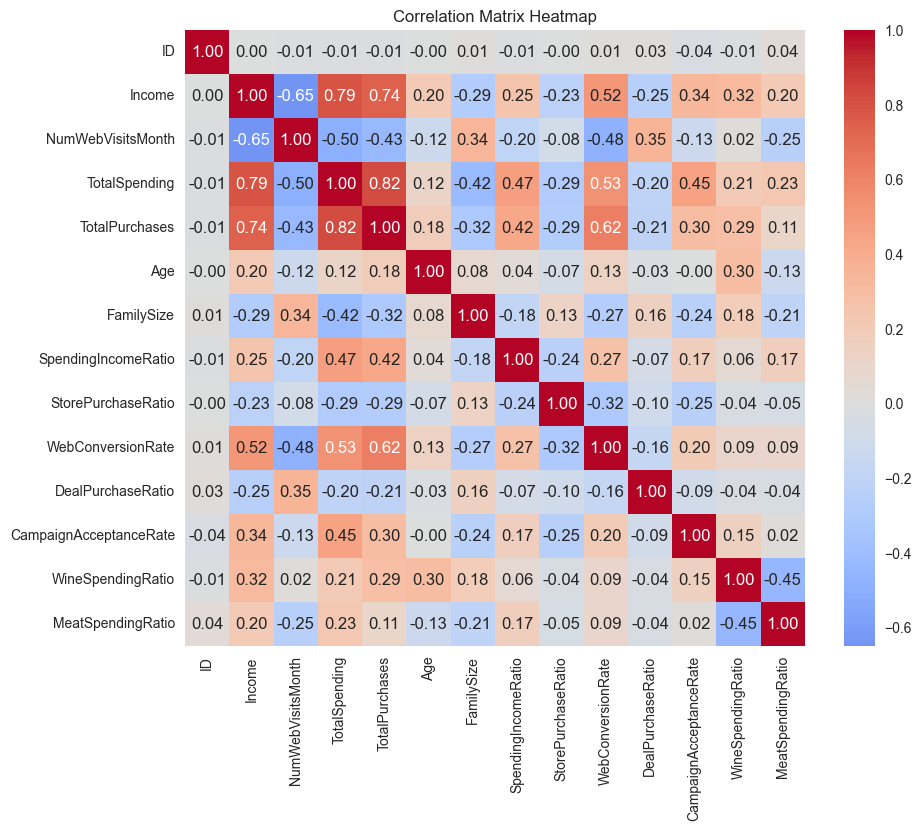

In [1422]:
# Select only numeric columns
corr_matrix = df.select_dtypes(include="number").corr()

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix Heatmap")
plt.show()

##### 9.2.2. Establishing PCA Variables

In [1423]:
candidate_columns = [
    "Income",
    "NumWebVisitsMonth",
    "TotalSpending",
    "TotalPurchases",
    "Age",
    "FamilySize",
    "SpendingIncomeRatio",
    "StorePurchaseRatio",
    "WebConversionRate",
    "DealPurchaseRatio",
    "WineSpendingRatio",
    "MeatSpendingRatio",
    "CampaignAcceptanceRate"
]

X = df[candidate_columns].copy()

#### 9.3. Feature Standardization

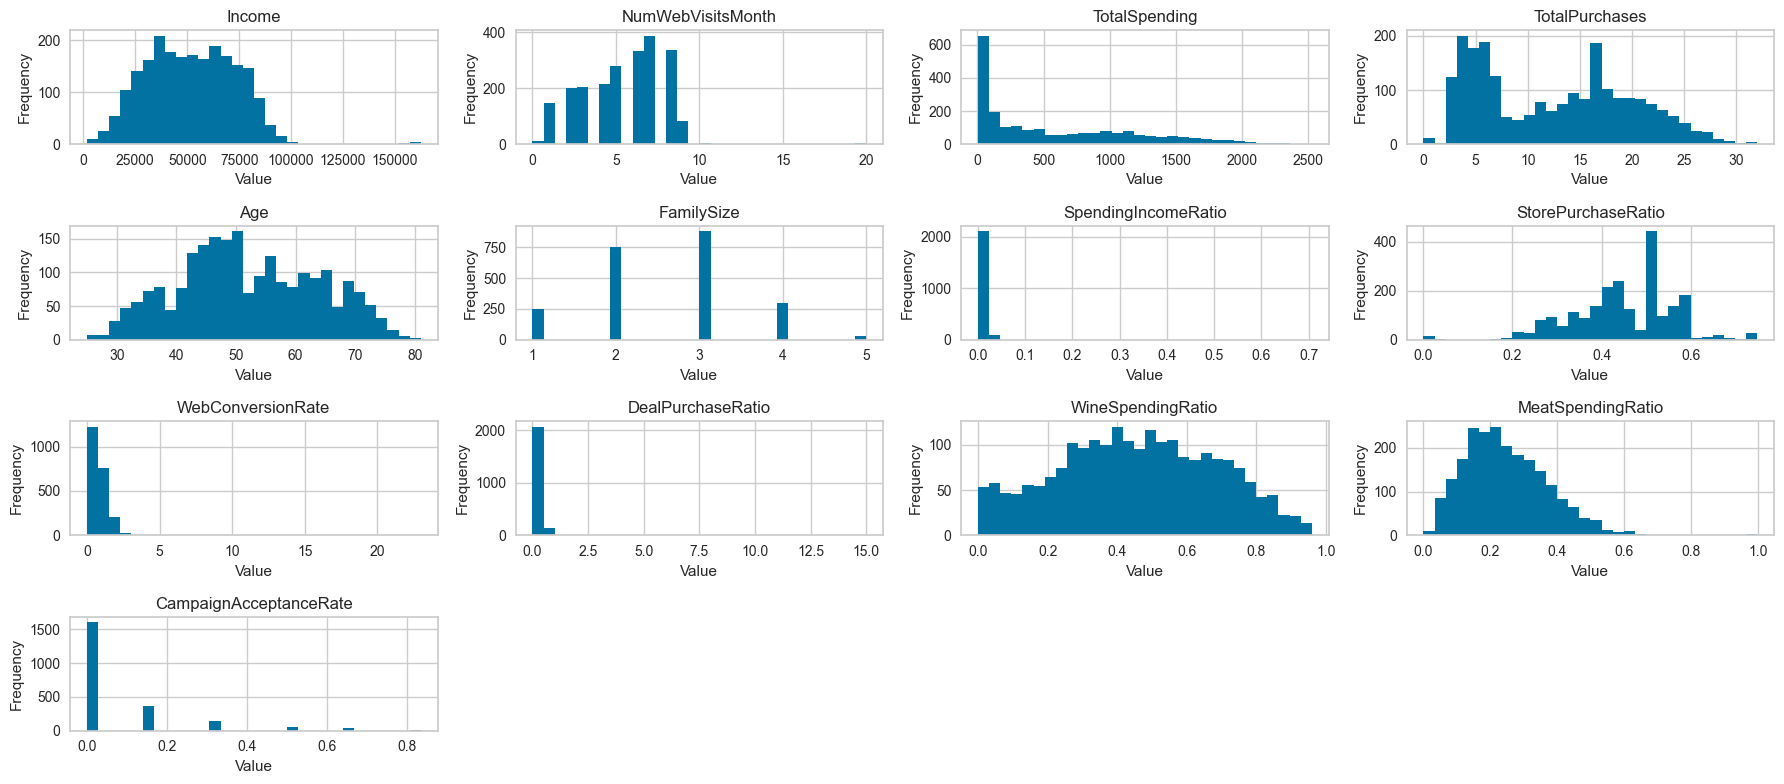

In [1424]:
n_cols = 4
n_rows = math.ceil(len(candidate_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(candidate_columns):
    axes[i].hist(df[col].dropna(), bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

for i in range(len(candidate_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [1425]:
log1p_cols = [
    "Income",
    "TotalSpending",
]

power_cols = [
    "SpendingIncomeRatio",
    "WebConversionRate",
    "DealPurchaseRatio",
    "CampaignAcceptanceRate"
]

scale_only_cols = [
    "NumWebVisitsMonth",
    "TotalPurchases",
    "Age",
    "FamilySize",
    "StorePurchaseRatio",
    "WineSpendingRatio",
    "MeatSpendingRatio",
]

In [1426]:
X_transformed = X.copy()

for col in log1p_cols:
    X_transformed[col] = pd.to_numeric(X_transformed[col], errors="coerce")
    X_transformed[col] = np.log1p(X_transformed[col])

for col in power_cols:
    X_transformed[col] = pd.to_numeric(X_transformed[col], errors="coerce")
    pt = PowerTransformer(method="yeo-johnson", standardize=False)
    X_transformed[[col]] = pt.fit_transform(X_transformed[[col]])

print(X_transformed[log1p_cols + power_cols].dtypes)
print(X_transformed[log1p_cols + power_cols].head())

Income                    float64
TotalSpending             float64
SpendingIncomeRatio       float64
WebConversionRate         float64
DealPurchaseRatio         float64
CampaignAcceptanceRate    float64
dtype: object
      Income  TotalSpending  SpendingIncomeRatio  WebConversionRate  \
0  10.970592       7.388946             0.015421           0.556393   
1  10.743869       3.332205             0.000575           0.146578   
2  11.179046       6.655440             0.008457           0.708960   
3  10.190432       3.988984             0.001897           0.231602   
4  10.973254       6.047372             0.006118           0.499683   

   DealPurchaseRatio  CampaignAcceptanceRate  
0           0.104870                0.068816  
1           0.223660               -0.000000  
2           0.043798               -0.000000  
3           0.184132               -0.000000  
4           0.202096               -0.000000  


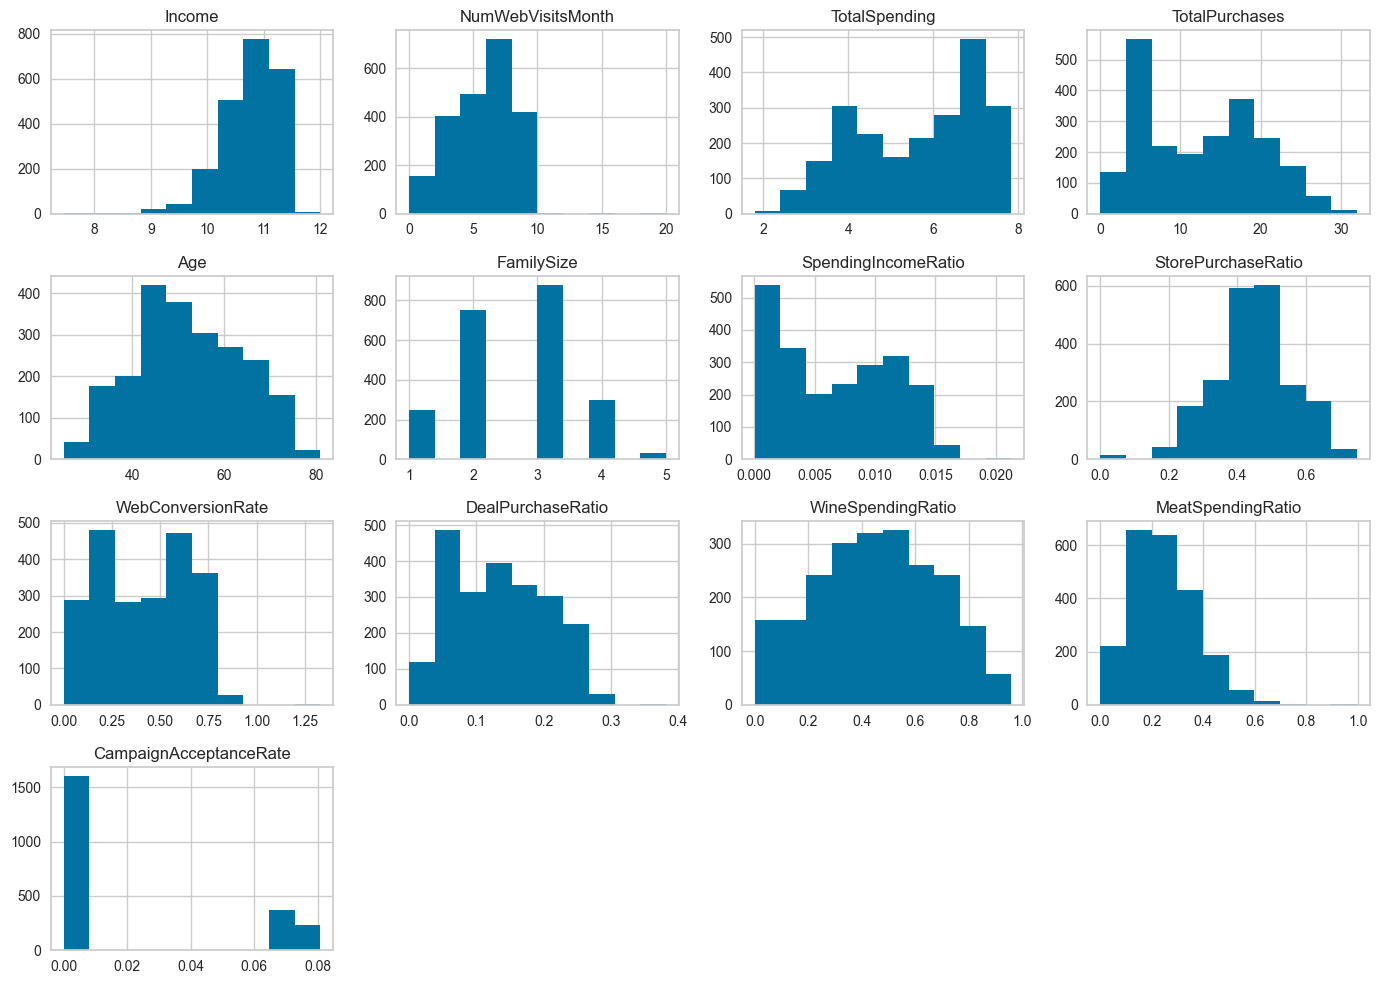

In [1427]:
X_transformed.hist(figsize=(14, 10))
plt.tight_layout()
plt.show()

In [1428]:
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X_transformed),
    columns=candidate_columns,
    index=df.index
)

display(X_scaled.head())
print(X_scaled.describe().round(2))

,Income,NumWebVisitsMonth,TotalSpending,TotalPurchases,Age,FamilySize,SpendingIncomeRatio,StorePurchaseRatio,WebConversionRate,DealPurchaseRatio,WineSpendingRatio,MeatSpendingRatio,CampaignAcceptanceRate
0,0.434624,0.692301,1.201427,1.309517,1.017915,-1.761762,1.845155,-2.362053,0.602652,-0.424226,-0.275049,0.728032,1.501953
1,-0.016033,-0.133077,-1.558496,-1.187746,1.274437,0.447193,-1.342726,-0.397081,-1.227700,1.243092,-0.273301,-0.259669,-0.610150
2,0.848966,-0.545767,0.702401,1.032044,0.333858,-0.657284,0.349871,0.265107,1.284063,-1.281415,0.410408,-0.667334,-0.610150
3,-1.116097,0.279612,-1.111670,-0.910272,-1.290779,0.447193,-1.058728,1.092842,-0.847959,0.688279,-1.105484,0.991995,-0.610150
4,0.439916,-0.133077,0.288714,0.199623,-1.034258,0.447193,-0.152343,-0.397081,0.349369,0.940420,-0.202353,0.258962,-0.610150


        Income  NumWebVisitsMonth  TotalSpending  TotalPurchases      Age  \
count  2208.00            2208.00        2208.00         2208.00  2208.00   
mean     -0.00              -0.00           0.00           -0.00     0.00   
std       1.00               1.00           1.00            1.00     1.00   
min      -6.55              -2.20          -2.61           -1.74    -2.32   
25%      -0.56              -0.96          -0.94           -0.91    -0.69   
50%       0.19               0.28           0.25           -0.08    -0.09   
75%       0.76               0.69           0.91            0.79     0.85   
max       2.48               6.06           1.50            2.70     2.47   

       FamilySize  SpendingIncomeRatio  StorePurchaseRatio  WebConversionRate  \
count     2208.00              2208.00             2208.00            2208.00   
mean         0.00                 0.00                0.00               0.00   
std          1.00                 1.00                1.00     

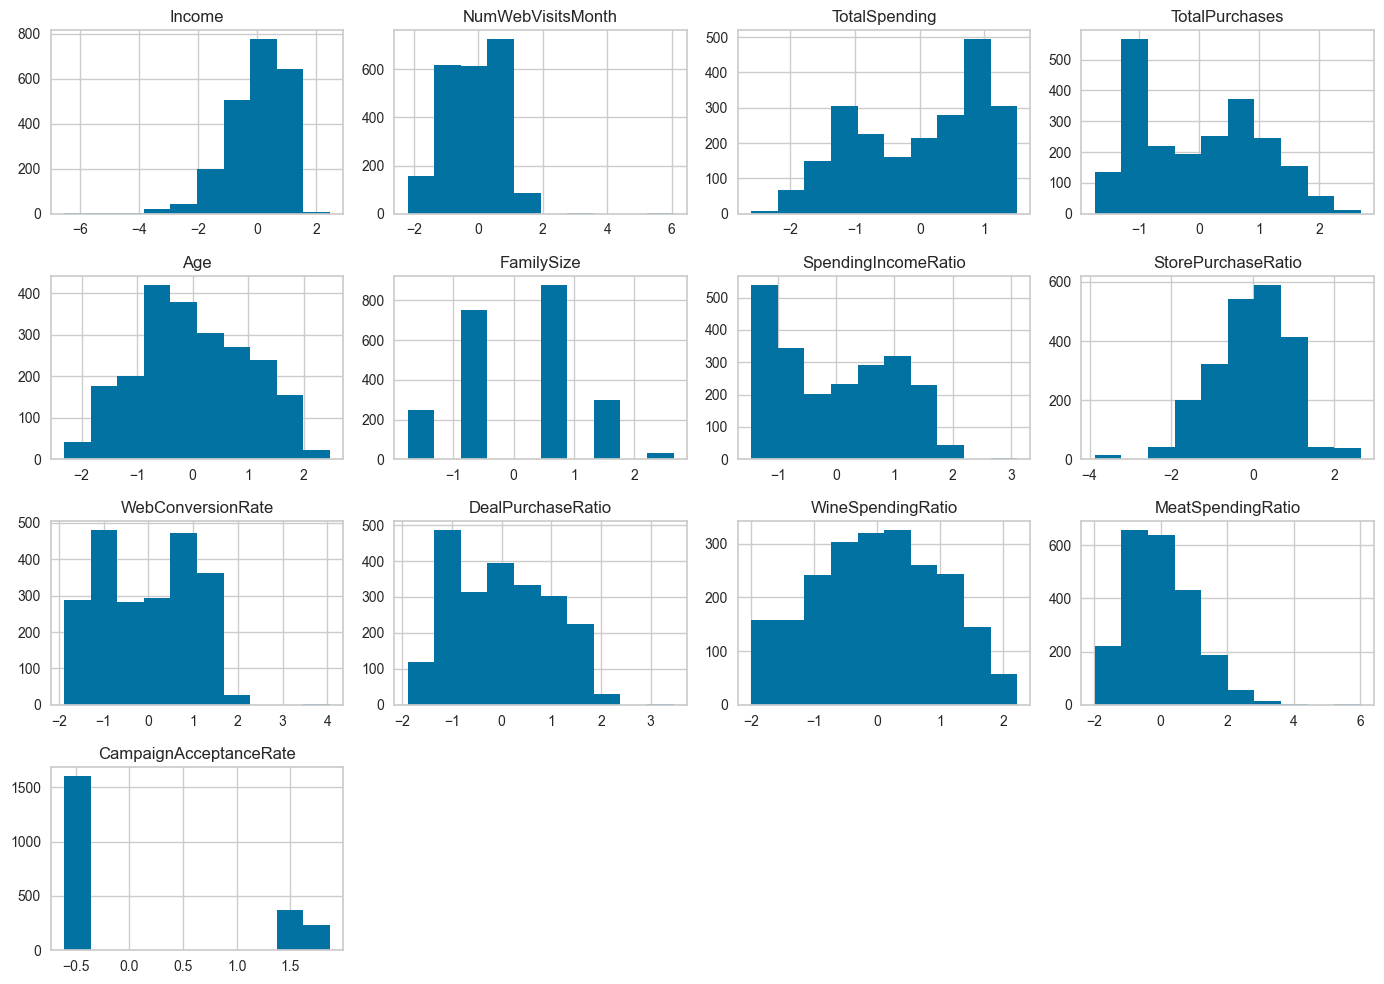

In [1429]:
X_scaled.hist(figsize=(14, 10))
plt.tight_layout()
plt.show()

#### 9.4. Principal Component Analysis

In [1430]:
# PCA brute-force search

@dataclass
class PCASearchConfig:
    candidate_columns: list[str]
    subset_min_size: int = 8
    subset_max_size: int | None = None
    max_subsets: int | None = None

    min_components: int = 2
    max_components: int | None = 5
    rotations: tuple[str | None, ...] = ("promax", "oblimin", "varimax")

    kmo_min: float = 0.70
    item_kmo_min: float = 0.45
    bartlett_p_max: float = 0.05

    min_communality: float = 0.30
    primary_loading_min: float = 0.40
    secondary_loading_max: float = 0.35
    min_loading_gap: float = 0.15
    max_cross_loading_items: int = 2
    min_items_per_component: int = 2

    min_total_explained_variance: float = 0.50
    require_eigenvalue_over_one: bool = False

    top_n: int = 20
    verbose: bool = True


def report_p_value(p: float) -> str:
    if p < 0.001:
        return "p < .001"
    return f"p = {p:.3f}".replace("0.", ".")


def _generate_subsets(
    columns: list[str],
    min_size: int,
    max_size: int | None,
    max_subsets: int | None,
) -> list[tuple[str, ...]]:
    max_size = max_size or len(columns)
    subsets: list[tuple[str, ...]] = []

    for size in range(min_size, max_size + 1):
        for combo in combinations(columns, size):
            subsets.append(combo)
            if max_subsets is not None and len(subsets) >= max_subsets:
                return subsets

    return subsets


def _compute_pca_loadings(
    data: pd.DataFrame,
    n_components: int,
    rotation: str | None,
) -> tuple[pd.DataFrame, list[float], float]:
    corr = data.corr()
    eigenvalues, eigenvectors = np.linalg.eigh(corr.to_numpy())

    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    retained_eigenvalues = eigenvalues[:n_components]
    retained_vectors = eigenvectors[:, :n_components]
    raw_loadings = retained_vectors * np.sqrt(retained_eigenvalues)

    if rotation is not None:
        rotated = Rotator(method=rotation).fit_transform(raw_loadings)
        loadings = pd.DataFrame(
            rotated,
            index=data.columns,
            columns=[f"PC{i + 1}" for i in range(n_components)],
        )
    else:
        loadings = pd.DataFrame(
            raw_loadings,
            index=data.columns,
            columns=[f"PC{i + 1}" for i in range(n_components)],
        )

    explained_variance = float(np.sum(retained_eigenvalues) / data.shape[1])
    return loadings, retained_eigenvalues.tolist(), explained_variance


def _primary_secondary(loadings: pd.DataFrame) -> tuple[pd.Series, pd.Series]:
    abs_loadings = loadings.abs().to_numpy()
    sorted_abs = np.sort(abs_loadings, axis=1)[:, ::-1]
    primary = pd.Series(sorted_abs[:, 0], index=loadings.index, name="primary_loading")

    if loadings.shape[1] > 1:
        secondary_vals = sorted_abs[:, 1]
    else:
        secondary_vals = np.zeros(loadings.shape[0])

    secondary = pd.Series(secondary_vals, index=loadings.index, name="secondary_loading")
    return primary, secondary


def _cross_loading_mask(
    loadings: pd.DataFrame,
    secondary_loading_max: float,
    min_loading_gap: float,
) -> pd.Series:
    primary, secondary = _primary_secondary(loadings)
    gap = primary - secondary
    return (secondary >= secondary_loading_max) | (gap < min_loading_gap)


def _items_per_component(
    loadings: pd.DataFrame,
    primary_loading_min: float,
) -> dict[str, int]:
    abs_loadings = loadings.abs()
    strongest_component = abs_loadings.idxmax(axis=1)
    strongest_value = abs_loadings.max(axis=1)
    valid = strongest_value >= primary_loading_min

    counts = {col: 0 for col in loadings.columns}
    for component in strongest_component[valid]:
        counts[str(component)] += 1
    return counts


def _highest_only_loadings(loadings: pd.DataFrame, decimals: int = 4) -> pd.DataFrame:
    highest_only = pd.DataFrame(
        np.nan,
        index=loadings.index,
        columns=loadings.columns,
    )

    strongest_component = loadings.abs().idxmax(axis=1)

    for variable, component in strongest_component.items():
        highest_only.loc[variable, component] = round(loadings.loc[variable, component], decimals)

    return highest_only


def brute_force_pca_search(
    data: pd.DataFrame,
    config: PCASearchConfig,
) -> tuple[pd.DataFrame, list[dict[str, Any]]]:
    candidate_data = data.loc[:, config.candidate_columns].copy()

    if candidate_data.isna().any().any():
        candidate_data = candidate_data.dropna(axis=0)

    bad_cols = [col for col in candidate_data.columns if candidate_data[col].nunique(dropna=True) <= 1]
    if bad_cols:
        raise ValueError(f"Remove constant columns first: {bad_cols}")

    subsets = _generate_subsets(
        columns=config.candidate_columns,
        min_size=config.subset_min_size,
        max_size=config.subset_max_size,
        max_subsets=config.max_subsets,
    )

    if config.verbose:
        print(f"Testing {len(subsets)} subsets from {len(config.candidate_columns)} candidate variables.")

    all_results: list[dict[str, Any]] = []

    for i, subset in enumerate(subsets, start=1):
        subset_df = candidate_data.loc[:, list(subset)]

        try:
            kmo_per_variable, kmo_overall = calculate_kmo(subset_df)
            chi_square_value, bartlett_p = calculate_bartlett_sphericity(subset_df)
        except Exception:
            continue

        item_kmo = pd.Series(kmo_per_variable, index=subset_df.columns, name="item_kmo")

        if kmo_overall < config.kmo_min:
            continue

        if item_kmo.min() < config.item_kmo_min:
            continue

        if bartlett_p > config.bartlett_p_max:
            continue

        max_components = min(
            config.max_components or (subset_df.shape[1] - 1),
            subset_df.shape[1] - 1,
        )
        min_components = min(config.min_components, max_components)

        if config.verbose and (i == 1 or i % 25 == 0 or i == len(subsets)):
            print(
                f"[{i}/{len(subsets)}] Current subset: {list(subset)} | "
                f"KMO={kmo_overall:.3f} | Bartlett {report_p_value(bartlett_p)}"
            )

        for n_components in range(min_components, max_components + 1):
            for rotation in config.rotations:
                try:
                    loadings, eigenvalues_retained, explained_variance = _compute_pca_loadings(
                        data=subset_df,
                        n_components=n_components,
                        rotation=rotation,
                    )
                except Exception:
                    continue

                communalities = (loadings**2).sum(axis=1).rename("communality")
                primary, secondary = _primary_secondary(loadings)
                cross_mask = _cross_loading_mask(
                    loadings=loadings,
                    secondary_loading_max=config.secondary_loading_max,
                    min_loading_gap=config.min_loading_gap,
                )
                cross_loading_items = loadings.index[cross_mask].tolist()
                items_per_component = _items_per_component(
                    loadings=loadings,
                    primary_loading_min=config.primary_loading_min,
                )
                highest_only_loadings = _highest_only_loadings(loadings.round(4))

                if config.require_eigenvalue_over_one and any(ev <= 1.0 for ev in eigenvalues_retained):
                    continue

                if explained_variance < config.min_total_explained_variance:
                    continue

                if communalities.min() < config.min_communality:
                    continue

                if primary.min() < config.primary_loading_min:
                    continue

                if int(cross_mask.sum()) > config.max_cross_loading_items:
                    continue

                if any(v < config.min_items_per_component for v in items_per_component.values()):
                    continue

                score = (
                    (float(kmo_overall) * 100.0)
                    + (explained_variance * 50.0)
                    + (float(communalities.mean()) * 20.0)
                    + (float(primary.mean()) * 20.0)
                    - (int(cross_mask.sum()) * 15.0)
                )

                all_results.append(
                    {
                        "variables": list(subset),
                        "n_variables": len(subset),
                        "n_components": n_components,
                        "rotation": rotation,
                        "kmo_overall": float(kmo_overall),
                        "min_item_kmo": float(item_kmo.min()),
                        "bartlett_p": float(bartlett_p),
                        "bartlett_report": report_p_value(float(bartlett_p)),
                        "chi_square_value": float(chi_square_value),
                        "explained_variance_ratio_sum": float(explained_variance),
                        "min_communality": float(communalities.min()),
                        "mean_communality": float(communalities.mean()),
                        "min_primary_loading": float(primary.min()),
                        "mean_primary_loading": float(primary.mean()),
                        "n_cross_loading_items": int(cross_mask.sum()),
                        "cross_loading_items": cross_loading_items,
                        "items_per_component": items_per_component,
                        "eigenvalues_retained": [float(v) for v in eigenvalues_retained],
                        "score": float(score),
                        "loadings": loadings.round(4),
                        "highest_only_loadings": highest_only_loadings,
                        "communalities": communalities.round(4),
                        "item_kmo": item_kmo.round(4),
                    }
                )

    all_results = sorted(
        all_results,
        key=lambda r: (
            -r["score"],
            -r["kmo_overall"],
            -r["explained_variance_ratio_sum"],
            -r["mean_communality"],
            -r["mean_primary_loading"],
            r["n_cross_loading_items"],
        ),
    )

    top_results = all_results[: config.top_n]

    summary_rows = []
    for result in top_results:
        summary_rows.append(
            {
                "variables": ", ".join(result["variables"]),
                "n_variables": result["n_variables"],
                "n_components": result["n_components"],
                "rotation": result["rotation"],
                "kmo_overall": result["kmo_overall"],
                "min_item_kmo": result["min_item_kmo"],
                "bartlett_p": result["bartlett_report"],
                "chi_square_value": result["chi_square_value"],
                "explained_variance_ratio_sum": result["explained_variance_ratio_sum"],
                "min_communality": result["min_communality"],
                "mean_communality": result["mean_communality"],
                "min_primary_loading": result["min_primary_loading"],
                "mean_primary_loading": result["mean_primary_loading"],
                "n_cross_loading_items": result["n_cross_loading_items"],
                "items_per_component": result["items_per_component"],
                "eigenvalues_retained": result["eigenvalues_retained"],
                "score": result["score"],
            }
        )

    summary_df = pd.DataFrame(summary_rows)
    return summary_df, top_results

In [1431]:
config = PCASearchConfig(
    candidate_columns=candidate_columns,
    subset_min_size=7,
    subset_max_size=8,
    max_subsets=None,
    min_components=2,
    max_components=2,
    rotations=("oblimin", "varimax"),
    kmo_min=0.80,
    item_kmo_min=0.45,
    bartlett_p_max=0.05,
    min_communality=0.30,
    primary_loading_min=0.40,
    secondary_loading_max=0.35,
    min_loading_gap=0.15,
    max_cross_loading_items=2,
    min_items_per_component=2,
    min_total_explained_variance=0.70,
    require_eigenvalue_over_one=False,
    top_n=20,
    verbose=True,
)

In [1432]:
pca_search_summary, pca_search_results = brute_force_pca_search(X_scaled, config)

if pca_search_results:
    best_model = pca_search_results[0]

    print("\nBest model summary:")
    print(f"Variables: {best_model['variables']}")
    print(f"Components: {best_model['n_components']}")
    print(f"Rotation: {best_model['rotation']}")
    print(f"Overall KMO: {best_model['kmo_overall']:.3f}")
    print(f"Minimum item KMO: {best_model['min_item_kmo']:.3f}")
    print(f"Bartlett's test: chi-square = {best_model['chi_square_value']:.3f}, {best_model['bartlett_report']}")
    print(f"Explained variance: {best_model['explained_variance_ratio_sum']:.3f}")
    print(f"Minimum communality: {best_model['min_communality']:.3f}")
    print(f"Mean communality: {best_model['mean_communality']:.3f}")
    print(f"Minimum primary loading: {best_model['min_primary_loading']:.3f}")
    print(f"Mean primary loading: {best_model['mean_primary_loading']:.3f}")
    print(f"Cross-loading items: {best_model['n_cross_loading_items']}")
    print(f"Items per component: {best_model['items_per_component']}")
    print(f"Eigenvalues retained: {[round(v, 3) for v in best_model['eigenvalues_retained']]}")

    print("\nBest model item KMO:")
    display(best_model["item_kmo"].to_frame())

    print("\nBest model communalities:")
    display(best_model["communalities"].to_frame())

    print("\nBest model highest loadings only:")
    display(best_model["highest_only_loadings"].fillna(""))

else:
    print("No PCA model passed the thresholds. Loosen the rules or reduce the candidate set.")

Testing 3003 subsets from 13 candidate variables.
[75/3003] Current subset: ['Income', 'NumWebVisitsMonth', 'TotalSpending', 'TotalPurchases', 'WebConversionRate', 'DealPurchaseRatio', 'WineSpendingRatio'] | KMO=0.828 | Bartlett p < .001
[475/3003] Current subset: ['Income', 'TotalSpending', 'TotalPurchases', 'Age', 'FamilySize', 'WebConversionRate', 'WineSpendingRatio'] | KMO=0.836 | Bartlett p < .001
[500/3003] Current subset: ['Income', 'TotalSpending', 'TotalPurchases', 'Age', 'StorePurchaseRatio', 'WebConversionRate', 'WineSpendingRatio'] | KMO=0.814 | Bartlett p < .001
[525/3003] Current subset: ['Income', 'TotalSpending', 'TotalPurchases', 'FamilySize', 'SpendingIncomeRatio', 'WebConversionRate', 'WineSpendingRatio'] | KMO=0.803 | Bartlett p < .001
[575/3003] Current subset: ['Income', 'TotalSpending', 'TotalPurchases', 'StorePurchaseRatio', 'WebConversionRate', 'DealPurchaseRatio', 'MeatSpendingRatio'] | KMO=0.851 | Bartlett p < .001
[750/3003] Current subset: ['Income', 'Total

,item_kmo
NumWebVisitsMonth,0.8092
TotalSpending,0.8096
TotalPurchases,0.9014
FamilySize,0.7882
SpendingIncomeRatio,0.8079
WebConversionRate,0.8733
DealPurchaseRatio,0.8595



Best model communalities:


,communality
NumWebVisitsMonth,0.4844
TotalSpending,0.9560
TotalPurchases,0.9678
FamilySize,0.8322
SpendingIncomeRatio,0.8968
WebConversionRate,0.7567
DealPurchaseRatio,0.5949



Best model highest loadings only:


,PC1,PC2
NumWebVisitsMonth,,0.6838
TotalSpending,0.9778,
TotalPurchases,0.9827,
FamilySize,,0.9016
SpendingIncomeRatio,0.947,
WebConversionRate,0.8604,
DealPurchaseRatio,,0.7322


In [1449]:
def plot_best_model_path_diagram(
    best_model: dict,
    loading_threshold: float = 0.15,
    figsize: tuple[float, float] = (5, 8),
    title: str = "Rotated Component Path Diagram",
) -> None:
    loadings = best_model["loadings"].copy()

    if loadings.empty:
        raise ValueError("best_model['loadings'] is empty.")

    loadings.columns = [f"RC{i + 1}" for i in range(loadings.shape[1])]

    if "uniqueness" in best_model:
        uniqueness = pd.Series(best_model["uniqueness"]).reindex(loadings.index)
    else:
        uniqueness = 1 - (loadings**2).sum(axis=1)
        uniqueness.name = "uniqueness"

    n_factors = loadings.shape[1]
    n_items = loadings.shape[0]

    fig, ax = plt.subplots(figsize=(4.8, 4))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    factor_x = 0.14
    item_x = 0.63
    factor_radius = 0.035
    box_width = 0.28
    box_height = min(0.06, 0.82 / max(n_items, 1))

    factor_fontsize = 10
    item_fontsize = 8
    title_fontsize = 11

    factor_y = np.linspace(0.76, 0.24, n_factors)
    item_y = np.linspace(0.90, 0.10, n_items)

    factor_pos = {col: (factor_x, y) for col, y in zip(loadings.columns, factor_y)}
    item_pos = {row: (item_x, y) for row, y in zip(loadings.index, item_y)}

    for factor_name, (x, y) in factor_pos.items():
        ax.add_patch(
            Circle(
                (x, y),
                factor_radius,
                facecolor="#f2f2f2",
                edgecolor="black",
                lw=0.8,
            )
        )
        ax.text(x, y, factor_name, ha="center", va="center", fontsize=factor_fontsize)

    for item_name, (x, y) in item_pos.items():
        ax.add_patch(
            Rectangle(
                (x - box_width / 2, y - box_height / 2),
                box_width,
                box_height,
                facecolor="#f7f7f7",
                edgecolor="#777777",
                lw=0.7,
            )
        )
        ax.text(x, y, str(item_name), ha="center", va="center", fontsize=item_fontsize)

        if pd.notna(uniqueness.get(item_name, np.nan)):
            ax.add_patch(
                FancyArrowPatch(
                    (0.96, y),
                    (x + box_width / 2, y),
                    arrowstyle="-|>",
                    mutation_scale=10,
                    lw=0.8,
                    color="#4caf50",
                    alpha=0.6,
                )
            )

    max_abs = float(np.abs(loadings.values).max())
    max_abs = max(max_abs, 1e-9)

    for item_name in loadings.index:
        for factor_name in loadings.columns:
            value = float(loadings.loc[item_name, factor_name])

            if math.isnan(value) or abs(value) < loading_threshold:
                continue

            fx, fy = factor_pos[factor_name]
            ix, iy = item_pos[item_name]

            ax.add_patch(
                FancyArrowPatch(
                    (fx + factor_radius * 0.95, fy),
                    (ix - box_width / 2, iy),
                    arrowstyle="-|>",
                    mutation_scale=10,
                    lw=0.4 + 2.8 * (abs(value) / max_abs),
                    color="darkgreen" if value >= 0 else "#d66a6a",
                    alpha=0.2 + 0.7 * (abs(value) / max_abs),
                    connectionstyle="arc3,rad=0.0",
                    shrinkA=0,
                    shrinkB=0,
                )
            )

    ax.set_title(title, fontsize=title_fontsize, pad=8)
    plt.tight_layout()
    plt.show()

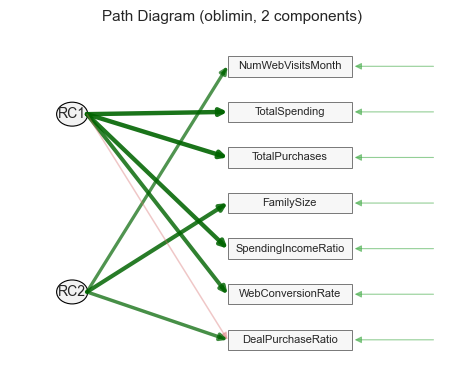

In [1450]:
plot_best_model_path_diagram(
    best_model=best_model,
    loading_threshold=0.15,
    figsize=(6, 4),
    title=f"Path Diagram ({best_model['rotation']}, {best_model['n_components']} components)",
)

In [1433]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_scores = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

In [1434]:
df_pca = pd.concat([X_scaled.reset_index(drop=True), pca_scores], axis=1)
df_pca.to_csv("data_with_pca.csv", index=False)